1. Load & inspect data

In [1]:
# for google colab
from google.colab import files #type: ignore
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d msambare/fer2013

!unzip -q fer2013.zip -d data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:04<00:00, 13.7MB/s]



In [2]:
import os, torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from PIL import Image

DATA_ROOT = "data/"   # contains train/ and test/

print("Dataset information: ")
# Base transform (no augmentation) — used for test
base_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = datasets.ImageFolder(DATA_ROOT + "train", transform=base_tf)
test_dataset  = datasets.ImageFolder(DATA_ROOT + "test",  transform=base_tf)

print("Train: ", len(train_dataset))
print("Test: ", len(test_dataset))
print("Total: ", len(train_dataset) + len(test_dataset))

print(train_dataset.class_to_idx)
# Verify counts
from collections import Counter
counts = Counter(train_dataset.targets)
print({train_dataset.classes[k]: v for k, v in counts.items()})


print("\nImages information: ")
img_path = "data/train/angry/Training_3908.jpg"
with Image.open(img_path) as img:
    print("Size: ", img.size)
    print("Mode: ", img.mode) # L: Grayscale (1 channel)
    print("Format: ", img.format)

Dataset information: 
Train:  28709
Test:  7178
Total:  35887
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}

Images information: 
Size:  (48, 48)
Mode:  L
Format:  JPEG


2. Data Preprocessing

In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

test_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT,"test"), transform=base_tf)

train_tf_alb = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CoarseDropout(num_holes_range=(1,4), hole_height_range=(1,8), hole_width_range=(1,8), p=0.3),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=0, p=0.4),
    A.Normalize(
    mean=[0.5],
    std=[0.5],
    max_pixel_value=255.0
    ),
    ToTensorV2(),
])

class AlbumentationsDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform):
        self.base = datasets.ImageFolder(root)
        self.tf = transform
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        img, label = self.base[i]
        img = np.array(img.convert("L"))   # grayscale np array
        aug = self.tf(image=img)
        return aug["image"], label

train_dataset_aug = AlbumentationsDataset(DATA_ROOT+"train", train_tf_alb)

In [4]:
# Generate extra augmented images for the disgust class and save to disk
disgust_dir = DATA_ROOT + "train/disgust"
imgs = [os.path.join(disgust_dir, f) for f in os.listdir(disgust_dir)]

extra_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.8),
    A.RandomBrightnessContrast(p=0.7),
    A.ElasticTransform(alpha=1, sigma=5, p=0.3),
])

target = 2500  # augment up to this count
import cv2
for idx in range(target - len(imgs)):
    src = imgs[idx % len(imgs)]
    img = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
    aug = extra_tf(image=img)["image"]
    out = os.path.join(disgust_dir, f"aug_{idx:04d}.png")
    cv2.imwrite(out, aug)

In [5]:
train_dataset_aug = AlbumentationsDataset(DATA_ROOT+"train", train_tf_alb)


# Build per-sample weights so each class is sampled equally
targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset_aug,
    batch_size=64,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

classes = train_dataset_aug.base.classes

print("--- COUNTER ---")
counts = Counter(train_dataset_aug.base.targets)
print({classes[k]: v for k, v in counts.items()})

print("\n--- UPDATED WEIGHT ---")
for i in range(len(classes)):
    print(f"{classes[i]:10} : {class_weights[i].item():.6f}")

--- COUNTER ---
{'angry': 3995, 'disgust': 2500, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}

--- UPDATED WEIGHT ---
angry      : 0.000250
disgust    : 0.002294
fear       : 0.000244
happy      : 0.000139
neutral    : 0.000201
sad        : 0.000207
surprise   : 0.000315


3. Choose architecture

In [6]:
import torchvision.models as models
import torch.nn as nn
import torch

def build_resnet18_fer(num_classes=7):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    old_conv_weight = model.conv1.weight.clone()
    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    with torch.no_grad():
        model.conv1.weight = nn.Parameter(old_conv_weight.sum(dim=1, keepdim=True) / 3.0)

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )

    return model

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_resnet18_fer(num_classes=7).to(device)

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


4. Training loop

In [9]:
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

scheduler = CosineAnnealingLR(optimizer, T_max=55, eta_min=1e-6)
# The learning deceleration cycle lasts exactly the same amount as the total number of Epochs (40 cycles).
# eta_min=1e-6: The minimum learning rate that the system is allowed to reduce to.

EPOCHS = 55
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train() # turn on train mode
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad() # delete memories
        logits = model(imgs) # predict
        loss = criterion(logits, labels) # validate
        loss.backward() # calculate gradient (learn from experience)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() # update weight
        total_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        n += len(labels)
    scheduler.step()

    # Validation phase
    # After completing an Epoch, the model must take a test to see if it has learned by rote.
    model.eval()
    val_correct, val_n = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            val_correct += (preds == labels).sum().item()
            val_n += len(labels)

    # Save the best model
    val_acc = val_correct / val_n
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
    print(f"Ep {epoch+1:3d}  loss={total_loss/n:.4f}  "
          f"train={correct/n:.3f}  val={val_acc:.3f}")


Ep   1  loss=1.4269  train=0.521  val=0.573
Ep   2  loss=1.1454  train=0.668  val=0.626
Ep   3  loss=1.0548  train=0.716  val=0.645
Ep   4  loss=1.0010  train=0.743  val=0.659
Ep   5  loss=0.9611  train=0.766  val=0.664
Ep   6  loss=0.9279  train=0.783  val=0.664
Ep   7  loss=0.9012  train=0.797  val=0.659
Ep   8  loss=0.8593  train=0.816  val=0.664
Ep   9  loss=0.8230  train=0.836  val=0.670
Ep  10  loss=0.7961  train=0.849  val=0.662
Ep  11  loss=0.7769  train=0.859  val=0.666
Ep  12  loss=0.7524  train=0.870  val=0.678
Ep  13  loss=0.7282  train=0.882  val=0.670
Ep  14  loss=0.7115  train=0.891  val=0.687
Ep  15  loss=0.6933  train=0.899  val=0.681
Ep  16  loss=0.6711  train=0.911  val=0.686
Ep  17  loss=0.6572  train=0.916  val=0.684
Ep  18  loss=0.6442  train=0.923  val=0.679
Ep  19  loss=0.6311  train=0.930  val=0.678
Ep  20  loss=0.6191  train=0.935  val=0.684
Ep  21  loss=0.6057  train=0.942  val=0.680
Ep  22  loss=0.5963  train=0.945  val=0.677
Ep  23  loss=0.5901  train=0.947

5. Evaluate & iterate

              precision    recall  f1-score   support

       angry       0.60      0.66      0.63       958
     disgust       0.93      0.70      0.80       111
        fear       0.54      0.58      0.56      1024
       happy       0.88      0.89      0.89      1774
     neutral       0.65      0.67      0.66      1233
         sad       0.59      0.61      0.60      1247
    surprise       0.88      0.66      0.75       831

    accuracy                           0.70      7178
   macro avg       0.73      0.68      0.70      7178
weighted avg       0.71      0.70      0.70      7178



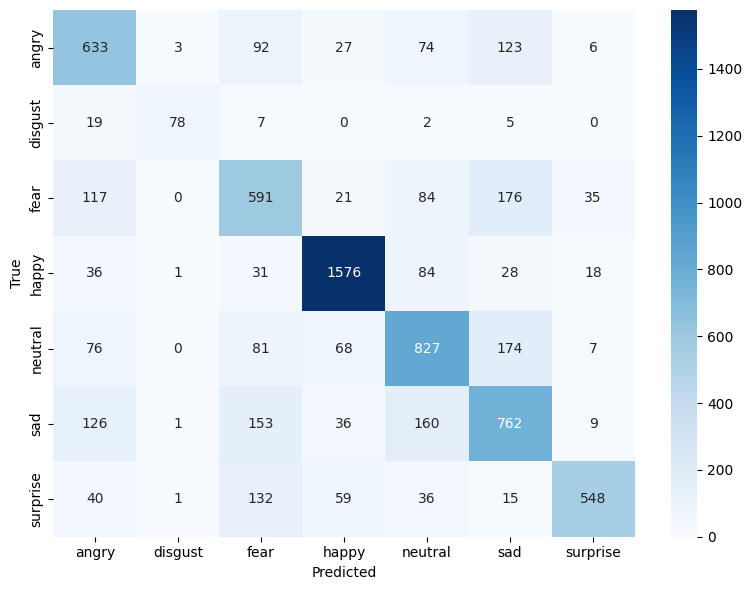

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

classes = train_dataset.classes
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes,
            yticklabels=classes, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150)


In [11]:
# Reload the best checkpoint so `model` matches the best validation accuracy,
# not just whatever epoch happened to finish last
model.load_state_dict(torch.load("best_model.pth"))

# Save a complete checkpoint with everything needed for inference or resuming training
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "epoch": EPOCHS,
    "best_val_acc": best_val_acc,
    "class_to_idx": train_dataset.class_to_idx,
}
torch.save(checkpoint, "fer_checkpoint.pth")

# Download to your machine (Colab)
from google.colab import files
files.download("fer_checkpoint.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>